In [1]:
import sys
import os
import pandas as pd
# Trỏ đường dẫn về thư mục gốc để import src
sys.path.append(os.path.abspath('..'))

from src.data.loader import DataLoader
from src.models.supervised import FailurePredictor

In [2]:
DATA_PATH = '../data/raw/ai4i2020.csv'
loader = DataLoader(DATA_PATH)
df = loader.load_data()

# Mã hóa cột 'Type' (L/M/H) thành số vì Mô hình máy học không hiểu chữ
# L=0, M=1, H=2
df['Type'] = df['Type'].map({'L': 0, 'M': 1, 'H': 2})
df.head()

-> Đã load dữ liệu: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,0,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,0,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


Số lượng tập train: 8000, Số lượng tập test: 2000
-> Đang huấn luyện mô hình Random Forest...

=== BÁO CÁO ĐÁNH GIÁ (CLASSIFICATION REPORT) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1932
           1       1.00      0.96      0.98        68

    accuracy                           1.00      2000
   macro avg       1.00      0.98      0.99      2000
weighted avg       1.00      1.00      1.00      2000

ROC-AUC Score: 0.9842
F1-Score: 0.9774


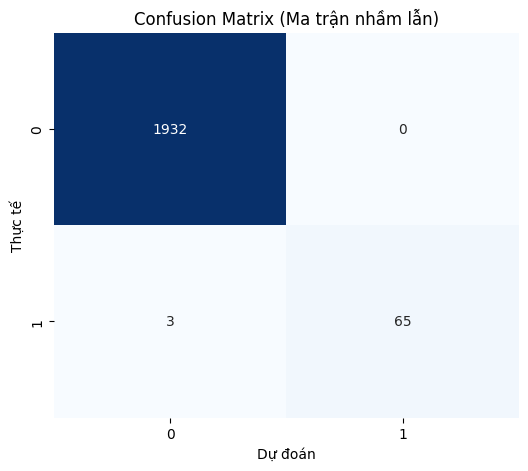

In [3]:
# 1. Khởi tạo mô hình
predictor = FailurePredictor()

# 2. Chia dữ liệu Train/Test
X_train, X_test, y_train, y_test = predictor.prepare_data(df, target_col='Machine failure')
print(f"Số lượng tập train: {X_train.shape[0]}, Số lượng tập test: {X_test.shape[0]}")

# 3. Huấn luyện
predictor.train(X_train, y_train)

# 4. Đánh giá kết quả
predictor.evaluate(X_test, y_test)

d:\BTL_KHAIPHADULIEU\src\models\supervised.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=indices.values, y=indices.index, palette='viridis')


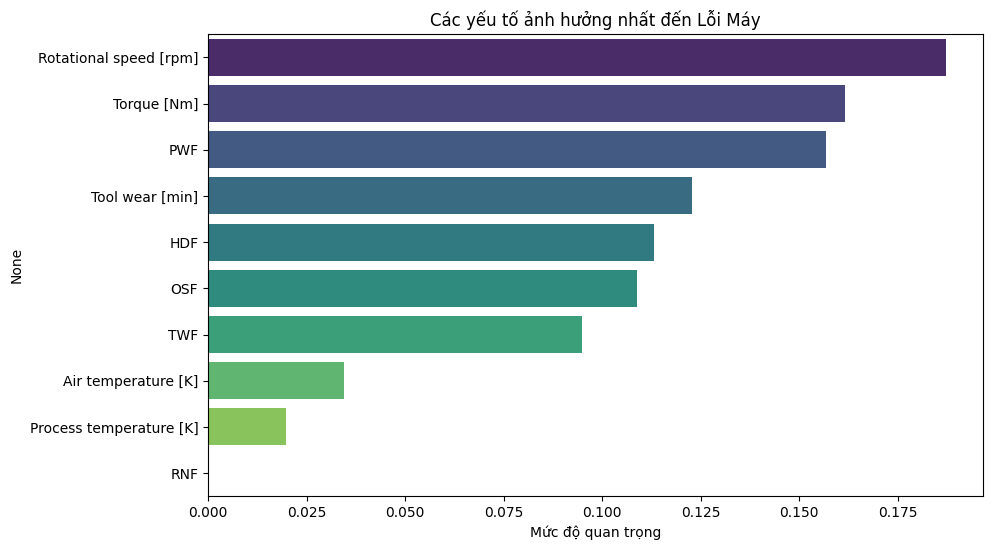

In [4]:
# Xem máy hỏng chủ yếu do nhiệt độ, hay do mòn dao, hay do tốc độ quay?
predictor.feature_importance()